In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
BASE = Path('/home/grads/tmp/roman_cs_baseline')
LOG_FILE = BASE / 'sweep_mead.log'
LOSSES_DIR = BASE / 'output_mead/losses'
MODEL_DIR = BASE / 'outpu_mead/models'

N_TRAIN_SIZES = [100000, 250000, 500000, 1000000]

In [19]:
# ============================================================================
# PLOT SETTINGS
# ============================================================================

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
plt.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
plt.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = '1.0'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = '0.0'
plt.rcParams['grid.alpha'] = '0.18'
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['legend.labelspacing'] = 0.77
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{tipa}'


plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 30,
    'axes.titlesize': 34,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 20,
    'figure.titlesize': 38
})


def format_log_labels(x, pos):
    if x >= 1:
        return f'{x:.0f}'
    elif x >= 0.1:
        return f'{x:.1f}'
    elif x >= 0.05 and x < 0.1:
        if x in [0.05, 0.06, 0.07, 0.08, 0.09]:
            return ''
        return f'{x:.2f}'
    elif x >= 0.01:
        return f'{x:.2f}'
    else:
        return f'{x:.3f}'

# Define color scheme
colors = {
    'truth': 'black',
    'high_acc': '#2E86AB',
    'low_acc': '#F18F01', 
    'transfer': '#A23B72'
}

In [20]:
def parse_sweep_log(log_file):
    results = {}
    current_n = None
    
    with open(log_file, 'r') as f:
        for line in f:
            if 'N_train =' in line:
                current_n = int(line.strip().split('N_train = ')[1])
                results[current_n] = {}
            if 'Mean   Delta Chi2' in line:
                results[current_n]['mean'] = float(line.strip().split('= ')[1])
            if 'Median Delta Chi2' in line:
                results[current_n]['median'] = float(line.strip().split('= ')[1])
            if 'N points with Chi2 > 0.2' in line:
                results[current_n]['n_outliers'] = int(line.strip().split(': ')[1])
    
    return results

results = parse_sweep_log(LOG_FILE)
results

{100000: {'mean': 0.005685, 'median': 0.002532, 'n_outliers': 16},
 250000: {'mean': 0.001977, 'median': 0.0008743, 'n_outliers': 7},
 500000: {}}

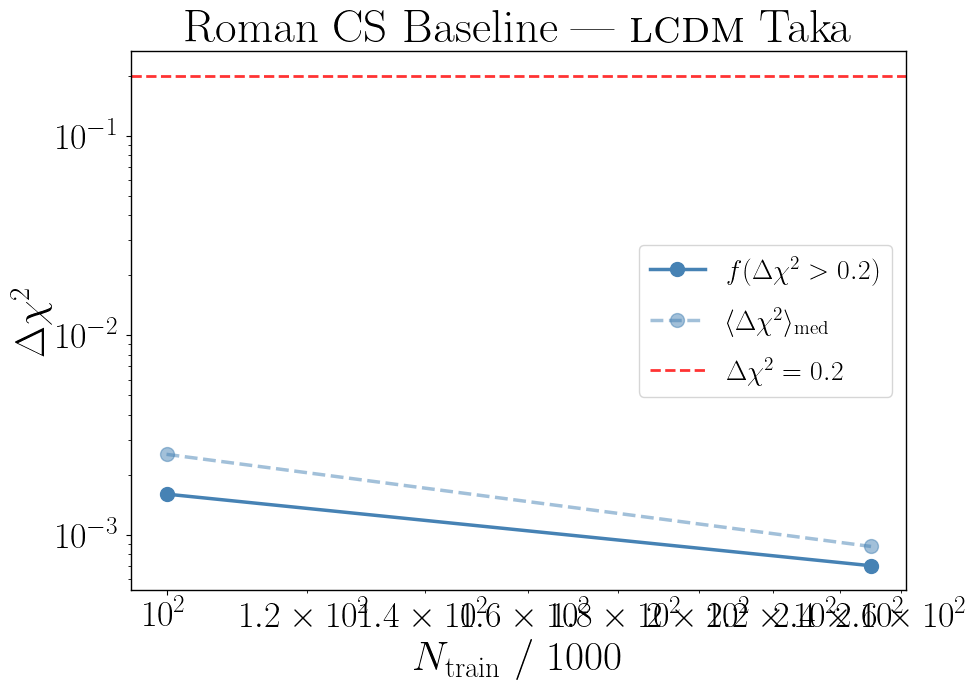

In [22]:
def plot_baseline_results(results, n_test=10000):
    sizes = sorted([n for n in results if results[n]])
    
    medians      = [results[n]['median'] for n in sizes]
    outlier_frac = [results[n]['n_outliers'] / n_test for n in sizes]
    sizes_k      = [n/1000 for n in sizes]
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.plot(sizes_k, outlier_frac, 'o-', color='steelblue', linewidth=2.5,
            markersize=10, label=r'$f(\Delta\chi^2 > 0.2)$')
    ax.plot(sizes_k, medians, 'o--', color='steelblue', linewidth=2.5,
            markersize=10, alpha=0.5, label=r'$\langle\Delta\chi^2\rangle_\mathrm{med}$')
    
    ax.axhline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.8,
               label=r'$\Delta\chi^2 = 0.2$')
    
    ax.set_xlabel(r'$N_\mathrm{train}\ /\ 1000$')
    ax.set_ylabel(r'$\Delta\chi^2$')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend()
    ax.set_title(r'Roman CS Baseline --- \textsc{lcdm} Taka')
    
    plt.savefig(BASE / 'output_mead/baseline_results.pdf', bbox_inches='tight', dpi=300, pad_inches=0.05)
    plt.show()

plot_baseline_results(results)

In [25]:
def plot_baseline_results(results, n_test=10000):
    sizes = sorted([n for n in results if results[n]])
    medians      = [results[n]['median'] for n in sizes]
    outlier_frac = [results[n]['n_outliers'] / n_test for n in sizes]
    sizes_k      = [n/1000 for n in sizes]
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(sizes_k, outlier_frac, 'o-', color='steelblue', linewidth=2.5,
            markersize=10, label=r'$f(\Delta\chi^2 > 0.2)$')
    ax.plot(sizes_k, medians, 'o--', color='steelblue', linewidth=2.5,
            markersize=10, alpha=0.5, label=r'$\langle\Delta\chi^2\rangle_\mathrm{med}$')
    ax.axhline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.8,
               label=r'$\Delta\chi^2 = 0.2$')
    ax.set_xlabel(r'$N_\mathrm{train}\ /\ 1000$')
    ax.set_ylabel(r'$\Delta\chi^2$')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend()
    ax.set_title(r'Roman CS Baseline --- \textsc{lcdm} Taka')
    plt.savefig(BASE / 'output/baseline_results.pdf', bbox_inches='tight', dpi=300, pad_inches=0.05)
    plt.show()
plot_baseline_results(results)
import torch
import h5py
import sys
sys.path.insert(0, '/home/grads/tmp/roman_cs_baseline')
from emulator import ResCNN
def load_and_evaluate(n_train, device='cpu'):
    model_path = MODEL_DIR / f'roman_cs_lcdm_taka_N{n_train}.pt'
    h5_path    = MODEL_DIR / f'roman_cs_lcdm_taka_N{n_train}.h5'
if not model_path.exists():
print(f'Model not found: {model_path}')
return None
# Load normalization
with h5py.File(h5_path, 'r') as f:
        samples_mean = torch.tensor(f['sample_mean'][:], dtype=torch.float32)
        samples_std  = torch.tensor(f['sample_std'][:],  dtype=torch.float32)
        dv_evals     = torch.tensor(f['dv_evals'][:],    dtype=torch.float32)
        dv_evecs     = torch.tensor(f['dv_evecs'][:],    dtype=torch.float32)
        dv_fid       = torch.tensor(f['dv_fid'][:],      dtype=torch.float32)
        train_params = list(f['train_params'][:])
# Load test data
    test_dv_path  = Path('/home/grads/backup/mltraining/yijie/roman_3x2_lcdm_taka/roman_real_lcdm_b_taka_test_datavectors.npy')
    test_par_path = Path('/home/grads/backup/mltraining/yijie/roman_3x2_lcdm_taka/roman_real_lcdm_b_taka_test_parameters.txt')
# Load and select correct parameter columns
    test_params_header = np.array(open(test_par_path).readline().split(' ')[1:])
    test_params_header[-1] = test_params_header[-1][:-1]
if isinstance(train_params[0], bytes):
        train_params = [p.decode() for p in train_params]
    idxs = [np.where(test_params_header == p)[0][0] for p in train_params]
    x_test = torch.tensor(np.loadtxt(test_par_path)[:, idxs], dtype=torch.float32)
    y_test = torch.tensor(np.load(test_dv_path)[:, :1080],     dtype=torch.float32)
# Preprocess
    x_test = (x_test - samples_mean) / samples_std
    y_test_norm = (y_test - dv_fid) @ dv_evecs / dv_evals
# Load model
    model = ResCNN(len(train_params), 1080, 256, 576, 21, 1)
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()
with torch.no_grad():
        y_pred = model(x_test)
        diff = y_test_norm - y_pred
        delta_chi2 = (diff**2).sum(dim=1).numpy()
return delta_chi2
# Load all available models
delta_chi2_all = {}
for n in N_TRAIN_SIZES:
print(f'Loading N={n}...')
    result = load_and_evaluate(n)
if result is not None:
        delta_chi2_all[n] = result
print(f'  median={np.median(result):.4f}, f>0.2={np.mean(result>0.2):.4f}')

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 42)

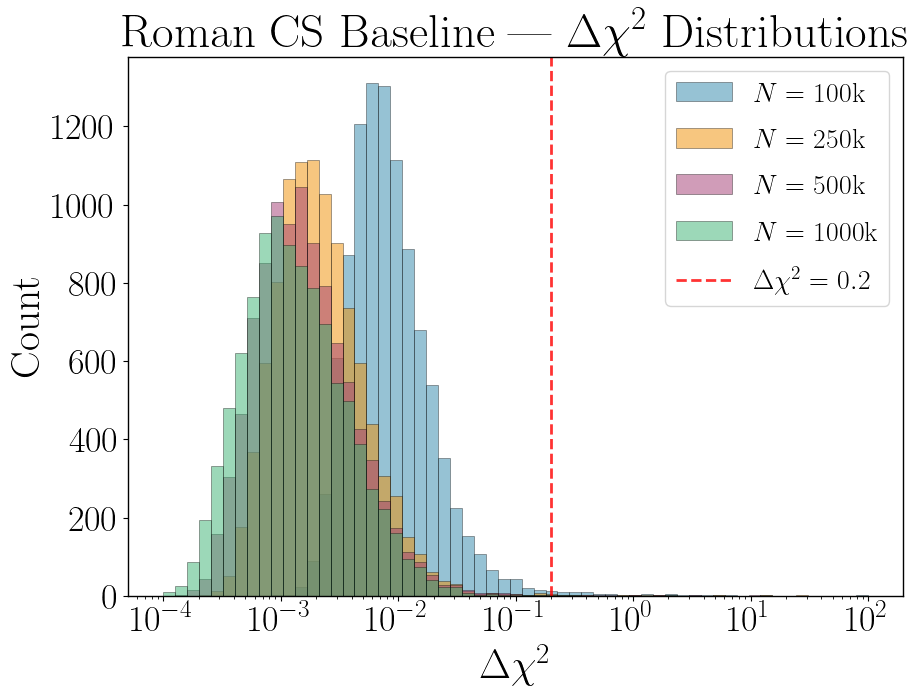

In [17]:
def plot_chi2_distributions(delta_chi2_all):
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors_n = {
        100000:  '#2E86AB',
        250000:  '#F18F01',
        500000:  '#A23B72',
        1000000: '#3BB273'
    }
    
    bins = np.logspace(-4, 2, 60)
    
    for n, delta_chi2 in sorted(delta_chi2_all.items()):
        ax.hist(delta_chi2, bins=bins, alpha=0.5, 
                color=colors_n[n], edgecolor='black', linewidth=0.5,
                label=rf'$N={n//1000}$k')
    
    ax.axvline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.8,
               label=r'$\Delta\chi^2 = 0.2$')
    
    ax.set_xscale('log')
    ax.set_xlabel(r'$\Delta\chi^2$')
    ax.set_ylabel(r'Count')
    ax.set_title(r'Roman CS Baseline --- $\Delta\chi^2$ Distributions')
    ax.legend()
    
    plt.savefig(BASE / 'output_taka/chi2_distributions.pdf', bbox_inches='tight', dpi=300, pad_inches=0.05)
    plt.show()

plot_chi2_distributions(delta_chi2_all)